<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/KA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
%load_ext cuml.accel

In [42]:
import pandas as pd
import numpy as np

In [43]:
train=pd.read_csv('/content/drive/MyDrive/Dataset/mlp ka2/train.csv')
train.head(3)

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0


In [44]:
test=pd.read_csv('/content/drive/MyDrive/Dataset/mlp ka2/test.csv')
test.head(3)

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
0,0,15765283,T'ien,645.0,France,Male,30.0,10,0.00,2.0,0.0,0.0,85901.09
1,1,15660157,Macleod,641.0,France,Male,37.0,10,146573.68,3.0,1.0,0.0,168023.72
2,2,15621267,Ejimofor,637.0,France,Female,32.0,6,0.00,1.0,0.0,0.0,148769.08


In [45]:
train=train.drop('id',axis=1)
test=test.drop('id',axis=1)

In [46]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       90000 non-null  int64  
 1   last_name         90000 non-null  object 
 2   credit_score      80444 non-null  float64
 3   country           83979 non-null  object 
 4   gender            90000 non-null  object 
 5   age               90000 non-null  float64
 6   tenure            90000 non-null  int64  
 7   acc_balance       82743 non-null  float64
 8   prod_count        85137 non-null  float64
 9   has_card          90000 non-null  float64
 10  is_active         90000 non-null  float64
 11  estimated_salary  90000 non-null  float64
 12  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(3), object(3)
memory usage: 8.9+ MB


In [47]:
train.isna().sum()

,0
customer_id,0
last_name,0
credit_score,9556
country,6021
gender,0
age,0
tenure,0
acc_balance,7257
prod_count,4863
has_card,0


In [48]:
train.isna().mean()*100

,0
customer_id,0.000000
last_name,0.000000
credit_score,10.617778
country,6.690000
gender,0.000000
age,0.000000
tenure,0.000000
acc_balance,8.063333
prod_count,5.403333
has_card,0.000000


checking if customer id is repeated or single customer id for every row.If customer id is unique for row every we can drop this column

In [49]:
train['customer_id'].value_counts(),len(train['customer_id'].unique())

(customer_id
 15682355    72
 15595588    56
 15585835    50
 15782530    50
 15648067    50
             ..
 15713352     1
 15744526     1
 15737524     1
 15622404     1
 15671355     1
 Name: count, Length: 18247, dtype: int64,
 18247)

so out of 90000,18247 customer id is unique and rest is repeated so for now we will not drop this column.


In [50]:
train[train.duplicated()].shape[0],test[test.duplicated()].shape[0]

(0, 0)

In [51]:
train.describe(include=np.number)

,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
count,9.000000e+04,80444.000000,90000.000000,90000.000000,82743.000000,85137.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,1.569209e+07,656.497054,38.119533,5.017022,55456.732147,1.552932,0.754289,0.497178,112394.659679,0.211600
std,7.129796e+04,80.016856,8.855203,2.804813,62788.474236,0.548011,0.430510,0.499995,50360.440702,0.408445
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.563361e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74430.360000,0.000000
50%,1.569016e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117505.070000,0.000000
75%,1.575674e+07,710.000000,42.000000,7.000000,119825.750000,2.000000,1.000000,1.000000,154874.787500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [52]:
train.describe(include=object)

,last_name,country,gender
count,90000,83979,90000
unique,2611,3,2
top,Hsia,France,Male
freq,1343,47966,50914


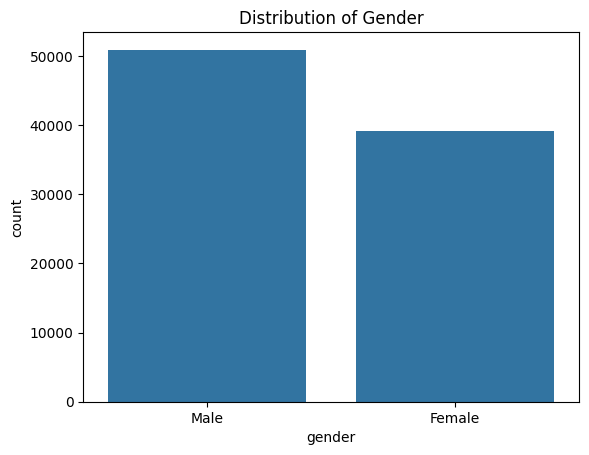

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(train,x='gender')
plt.title('Distribution of Gender')
plt.show()

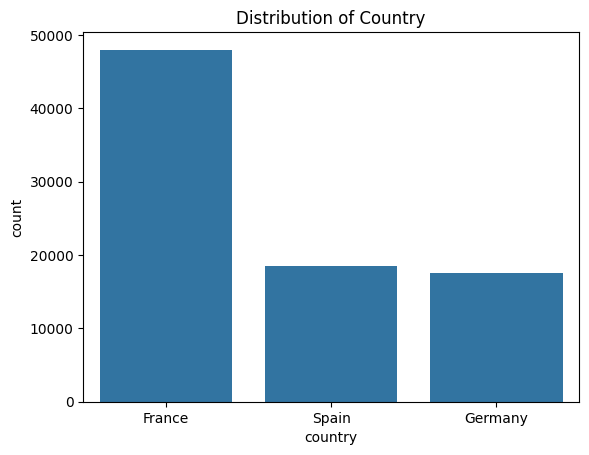

In [54]:
sns.countplot(train,x='country')
plt.title('Distribution of Country')
plt.show()

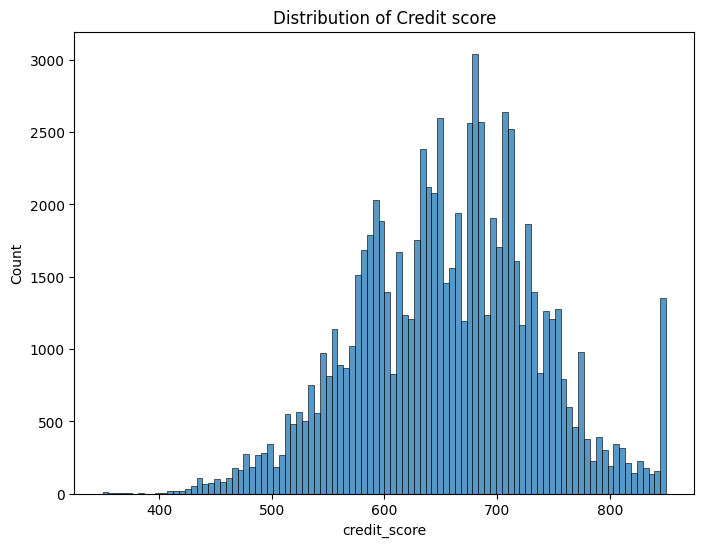

In [55]:

plt.figure(figsize=(8,6))
sns.histplot(train['credit_score'])
plt.title('Distribution of Credit score')
plt.show()

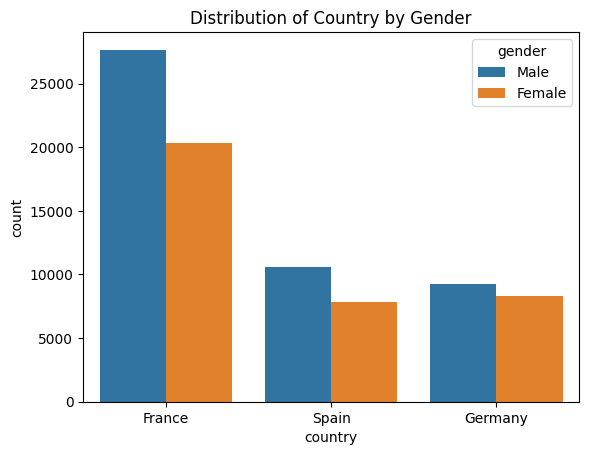

In [56]:
sns.countplot(train,x='country',hue='gender')
plt.title('Distribution of Country by Gender')
plt.show()

In [57]:
country_by_cs=train.groupby('country')['credit_score'].mean().reset_index()
country_by_cs


,country,credit_score
0,France,655.778353
1,Germany,657.435231
2,Spain,657.179819


In [58]:
print('Country having highest credit score',country_by_cs.max())
print("-"*50)
print('Country having lowest credit score',country_by_cs.min())

Country having highest credit score country              Spain
credit_score    657.435231
dtype: object
--------------------------------------------------
Country having lowest credit score country             France
credit_score    655.778353
dtype: object


In [59]:
gender_cs=train.groupby('gender')['credit_score'].mean().reset_index()
gender_cs

,gender,credit_score
0,Female,656.477567
1,Male,656.511989


In [60]:
print('Gender having highest credit score',gender_cs.max())
print("-"*50)
print('Gender having lowest credit score',gender_cs.min())

Gender having highest credit score gender                Male
credit_score    656.511989
dtype: object
--------------------------------------------------
Gender having lowest credit score gender              Female
credit_score    656.477567
dtype: object


In [61]:
gender_es=train.groupby('gender')['estimated_salary'].mean().reset_index()
gender_es

,gender,estimated_salary
0,Female,112939.972596
1,Male,111976.030213


In [62]:
print('Gender having highest estimated salary',gender_es.max())
print("-"*50)
print('Gender having lowest estimated salary',gender_es.min())

Gender having highest estimated salary gender                       Male
estimated_salary    112939.972596
dtype: object
--------------------------------------------------
Gender having lowest estimated salary gender                     Female
estimated_salary    111976.030213
dtype: object


Corelattion of data

In [63]:
train.describe(include=np.number)


,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
count,9.000000e+04,80444.000000,90000.000000,90000.000000,82743.000000,85137.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,1.569209e+07,656.497054,38.119533,5.017022,55456.732147,1.552932,0.754289,0.497178,112394.659679,0.211600
std,7.129796e+04,80.016856,8.855203,2.804813,62788.474236,0.548011,0.430510,0.499995,50360.440702,0.408445
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.563361e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74430.360000,0.000000
50%,1.569016e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117505.070000,0.000000
75%,1.575674e+07,710.000000,42.000000,7.000000,119825.750000,2.000000,1.000000,1.000000,154874.787500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [64]:
cor=train.corr(numeric_only=True)
cor

,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
customer_id,1.000000,0.006491,0.000387,0.001617,-0.002177,0.003208,-0.004521,-0.001489,0.002135,-0.015658
credit_score,0.006491,1.000000,-0.004102,-0.001783,0.007504,0.008284,-0.002005,0.016239,-0.003851,-0.028124
age,0.000387,-0.004102,1.000000,-0.010781,0.065456,-0.101880,-0.010206,0.004470,-0.005994,0.341628
tenure,0.001617,-0.001783,-0.010781,1.000000,-0.007877,0.009988,0.007669,-0.002913,0.001542,-0.021116
acc_balance,-0.002177,0.007504,0.065456,-0.007877,1.000000,-0.361765,-0.019071,-0.018503,0.008697,0.129074
prod_count,0.003208,0.008284,-0.101880,0.009988,-0.361765,1.000000,0.009519,0.040933,-0.005479,-0.211946
has_card,-0.004521,-0.002005,-0.010206,0.007669,-0.019071,0.009519,1.000000,-0.024953,0.006804,-0.021654
is_active,-0.001489,0.016239,0.004470,-0.002913,-0.018503,0.040933,-0.024953,1.000000,-0.007370,-0.211661
estimated_salary,0.002135,-0.003851,-0.005994,0.001542,0.008697,-0.005479,0.006804,-0.007370,1.000000,0.022206
exit_status,-0.015658,-0.028124,0.341628,-0.021116,0.129074,-0.211946,-0.021654,-0.211661,0.022206,1.000000


In [65]:
cor['exit_status'].sort_values(ascending=False)

,exit_status
exit_status,1.000000
age,0.341628
acc_balance,0.129074
estimated_salary,0.022206
customer_id,-0.015658
tenure,-0.021116
has_card,-0.021654
credit_score,-0.028124
is_active,-0.211661
prod_count,-0.211946


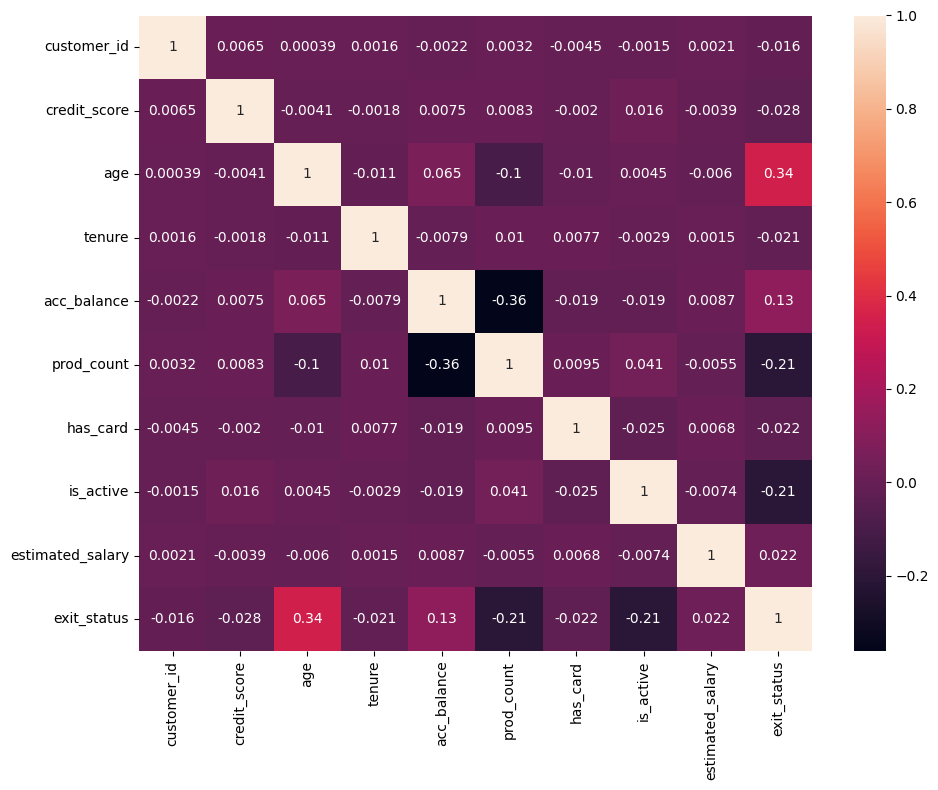

In [66]:
plt.figure(figsize=(10,8))
sns.heatmap(cor,annot=True)
plt.tight_layout()
plt.show()

Checking if value of age,prod_count column is negative or not.

In [67]:
for i in train[['age','prod_count','tenure','estimated_salary','has_card','is_active','credit_score']]:
    print("value less than 0 for ",i,train[train[i]<0].shape[0])

value less than 0 for  age 0
value less than 0 for  prod_count 0
value less than 0 for  tenure 0
value less than 0 for  estimated_salary 0
value less than 0 for  has_card 0
value less than 0 for  is_active 0
value less than 0 for  credit_score 0


In [68]:
train['has_card'].unique(),train['is_active'].unique()

(array([1., 0.]), array([1., 0.]))

In [69]:
feature=train.drop('exit_status',axis=1)
labels=train['exit_status'].copy()

In [70]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
num_pipe=Pipeline([
    ('num_feature',SimpleImputer(strategy='mean')),
    ('num_scaler',StandardScaler())

])
cat_pipe=Pipeline([
    ('num_feature',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
])
lastName_pipe=Pipeline([
    ('last_name_encoder',OrdinalEncoder(handle_unknown='use_encoded_value',encoded_missing_value=-1,unknown_value=-2))
])

In [71]:
## Column Transformer
num_col=['age','prod_count','tenure','estimated_salary','credit_score','acc_balance']
cat_col=['country','gender']
transformer=ColumnTransformer([
    ('num_pipe',num_pipe,num_col),
    ('cat_pipe',cat_pipe,cat_col),
    ('last_nm',lastName_pipe,['last_name'])
],remainder='passthrough',verbose_feature_names_out=False).set_output(transform='pandas')
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_pipe',
                                 Pipeline(steps=[('num_feature',
                                                  SimpleImputer()),
                                                 ('num_scaler',
                                                  StandardScaler())]),
                                 ['age', 'prod_count', 'tenure',
                                  'estimated_salary', 'credit_score',
                                  'acc_balance']),
                                ('cat_pipe',
                                 Pipeline(steps=[('num_feature',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['country', 'gender']),
                                ('last_nm',
                                 Pipeline(steps=[('last_name_encoder',
                                                  OrdinalEncoder(encoded_missing_value=-1,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-2))]),
                                 ['last_name'])],
                  verbose_feature_names_out=False)

In [72]:
train_df=transformer.fit_transform(feature)
test_df=transformer.transform(test)

train_df=transformer.fit_transform(feature)
test_df=transformer.transform(test)

Feature engineering

In [73]:
train_df.head(3)

,age,prod_count,tenure,estimated_salary,credit_score,acc_balance,country_Germany,country_Spain,country_nan,gender_Male,last_name,customer_id,has_card,is_active
0,-1.142785,-1.037403,-1.432197,-0.889040,-1.288805,1.570219e+00,0.0,0.0,0.0,1.0,1158.0,15788291,1.0,1.0
1,-0.126427,0.838781,0.706995,1.397994,0.495748,9.809002e-01,0.0,0.0,0.0,0.0,1091.0,15642816,0.0,0.0
2,0.777001,0.838781,1.063527,1.150586,-0.945113,1.208561e-16,0.0,0.0,1.0,0.0,2279.0,15632272,1.0,1.0


In [74]:
train_df.isnull().sum().sum(),test_df.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [75]:
for i in train_df[['age','prod_count','tenure','estimated_salary','credit_score','acc_balance']]:
    print("var of",i,np.var(train_df[i]))

var of age 1.0000000000002078
var of prod_count 0.9999999999995294
var of tenure 1.0000000000000904
var of estimated_salary 1.000000000000008
var of credit_score 1.0000000000000193
var of acc_balance 0.9999999999998797


In [76]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(train_df,labels,random_state=42,test_size=0.2,shuffle=True)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(72000, 14) (72000,)
(18000, 14) (18000,)


In [77]:
X_train.head(3)

,age,prod_count,tenure,estimated_salary,credit_score,acc_balance,country_Germany,country_Spain,country_nan,gender_Male,last_name,customer_id,has_card,is_active
51004,-0.916927,0.838781,1.420059,0.594462,1.502816e-15,-0.921155,0.0,1.0,0.0,0.0,1430.0,15765257,1.0,0.0
11453,0.099430,0.838781,-1.075665,-1.122429,-8.261429e-01,-0.921155,0.0,0.0,0.0,1.0,1690.0,15768124,1.0,1.0
9691,-0.465213,-1.037403,0.350463,0.678958,1.249226e+00,1.447174,1.0,0.0,0.0,0.0,2145.0,15672994,1.0,0.0


Base Model's Score


In [80]:
from sklearn.linear_model import  LogisticRegression,Perceptron,SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,HistGradientBoostingClassifier,StackingClassifier,IsolationForest,BaggingClassifier,ExtraTreesClassifier

In [81]:
score=dict()
models={
    "LogisticRegression": LogisticRegression(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "SGDClassifier":SGDClassifier(random_state=42,n_jobs=-1),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(random_state=42),
    "BaggingClassifier": BaggingClassifier(random_state=42),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42),
    "Perceptron": Perceptron(random_state=42),
    "SVC":SVC()
}
for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    f1=f1_score(y_test,pred)
    score[name]=f1
score

{'LogisticRegression': 0.0,
 'RandomForestClassifier': 0.6014847575422524,
 'SGDClassifier': 0.0,
 'AdaBoostClassifier': 0.5976205003050641,
 'HistGradientBoostingClassifier': 0.6207214121258634,
 'BaggingClassifier': 0.5732444582235312,
 'ExtraTreesClassifier': 0.5786882642528188,
 'Perceptron': 0.34794181083933734,
 'SVC': 0.0}

In [108]:
model_score_df=pd.DataFrame.from_dict(score,orient='index',columns=['f1'])
model_score_df

,f1
LogisticRegression,0.000000
RandomForestClassifier,0.601485
SGDClassifier,0.000000
AdaBoostClassifier,0.597621
HistGradientBoostingClassifier,0.620721
BaggingClassifier,0.573244
ExtraTreesClassifier,0.578688
Perceptron,0.347942
SVC,0.000000


In [109]:
model_score_df.nlargest(3,'f1')

,f1
HistGradientBoostingClassifier,0.620721
RandomForestClassifier,0.601485
AdaBoostClassifier,0.597621
